In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
SOURCE_PATH = "/content/drive/My Drive/Colab Notebooks/datasheet/"

In [7]:
SAVE_PATH = "/content/drive/My Drive/Colab Notebooks/datasheet_event2000_2"

EVENT_SIZE = 2000

os.makedirs(SAVE_PATH, exist_ok=True)

In [8]:
def split_to_events(df, event_size=2000):

    events = []

    total = len(df)

    for start in range(
        0,
        total - event_size + 1,
        event_size
    ):

        end = start + event_size

        events.append(
            df.iloc[start:end].copy()
        )

    return events

In [9]:
classes = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

for cls in classes:

    print("\nPROCESS :", cls)

    src_folder = os.path.join(
        SOURCE_PATH,
        cls
    )

    dst_folder = os.path.join(
        SAVE_PATH,
        cls
    )

    os.makedirs(
        dst_folder,
        exist_ok=True
    )

    files = os.listdir(src_folder)

    for file in files:

        fp = os.path.join(
            src_folder,
            file
        )

        try:

            df = pd.read_csv(fp)

            # KELAS NORMAL


            if cls in ["diam", "jalan"]:

                events = split_to_events(
                    df,
                    EVENT_SIZE
                )

                for i, event_df in enumerate(events):

                    save_name = (
                        file.replace(
                            ".csv",
                            f"_part{i+1}.csv"
                        )
                    )

                    event_df.to_csv(
                        os.path.join(
                            dst_folder,
                            save_name
                        ),
                        index=False
                    )

            # KELAS JATUH

            else:

                if len(df) < EVENT_SIZE:

                    print(
                        "SKIP",
                        file,
                        len(df)
                    )

                    continue

                event_df = df.iloc[:EVENT_SIZE]

                event_df.to_csv(
                    os.path.join(
                        dst_folder,
                        file
                    ),
                    index=False
                )

        except Exception as e:

            print(
                "ERROR :",
                file
            )

            print(e)


PROCESS : diam

PROCESS : jalan

PROCESS : diamjatuh

PROCESS : jalanjatuh


In [10]:
classes = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

for cls in classes:

    folder = os.path.join(
        SAVE_PATH,
        cls
    )

    files = os.listdir(folder)

    print(
        cls,
        ":",
        len(files),
        "event"
    )

diam : 54 event
jalan : 52 event
diamjatuh : 61 event
jalanjatuh : 76 event


In [11]:
all_info = []

for cls in classes:

    folder = os.path.join(
        SAVE_PATH,
        cls
    )

    files = os.listdir(folder)

    for f in files:

        fp = os.path.join(
            folder,
            f
        )

        df = pd.read_csv(fp)

        all_info.append([
            cls,
            f,
            len(df)
        ])

info_df = pd.DataFrame(
    all_info,
    columns=[
        "class",
        "file",
        "samples"
    ]
)

info_df["samples"].describe()

,samples
count,243.0
mean,2000.0
std,0.0
min,2000.0
25%,2000.0
50%,2000.0
75%,2000.0
max,2000.0


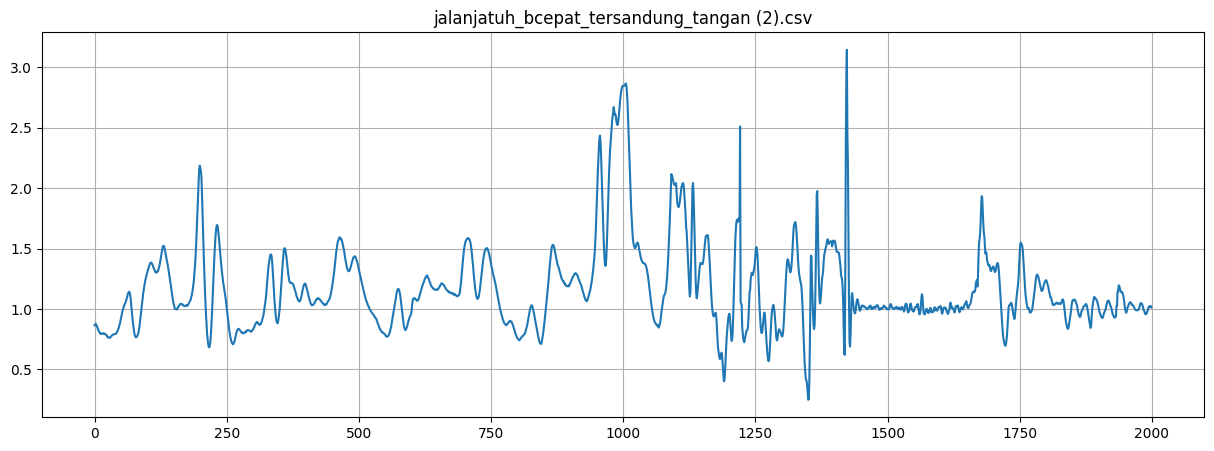

In [12]:
target_class = "jalanjatuh"

folder = os.path.join(
    SAVE_PATH,
    target_class
)

file = np.random.choice(
    os.listdir(folder)
)

fp = os.path.join(
    folder,
    file
)

df = pd.read_csv(fp)

acc_mag = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)

plt.figure(figsize=(15,5))

plt.plot(acc_mag)

plt.title(file)

plt.grid()

plt.show()

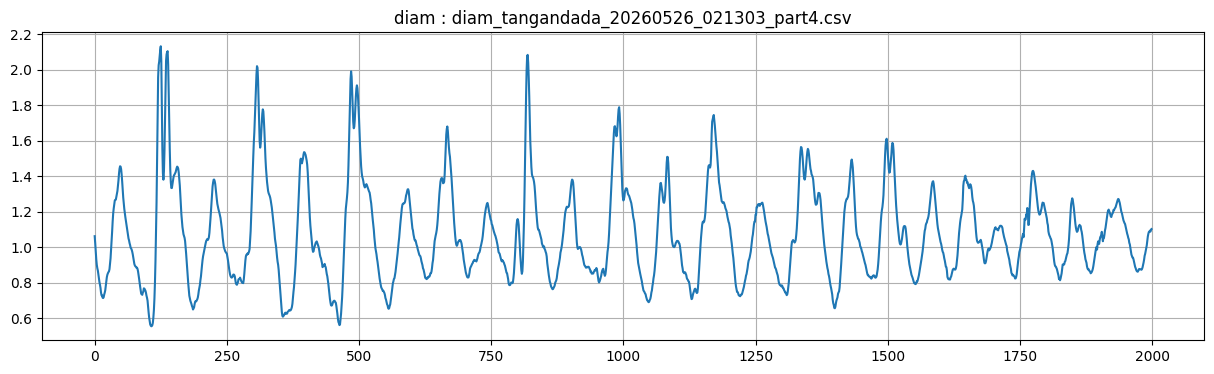

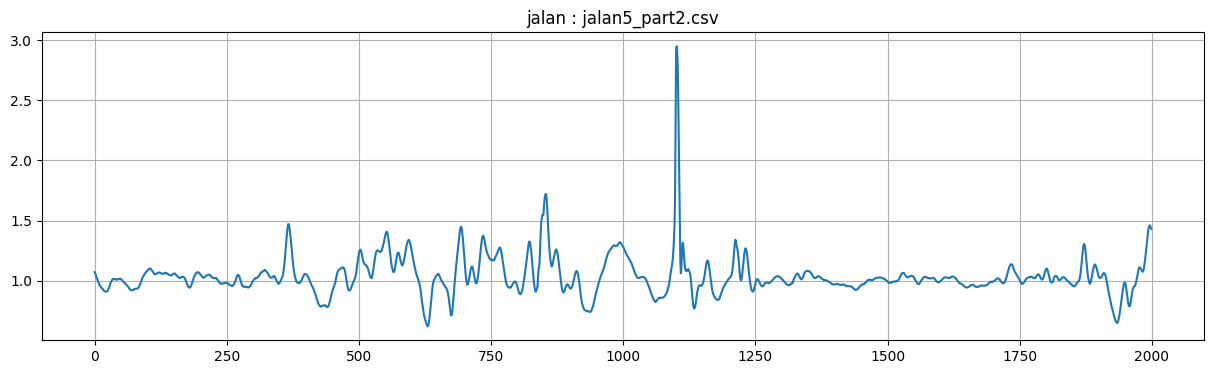

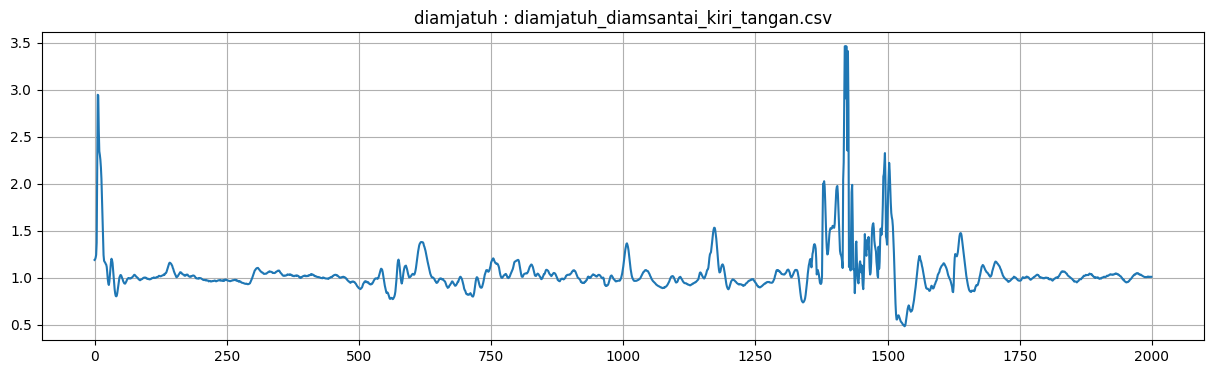

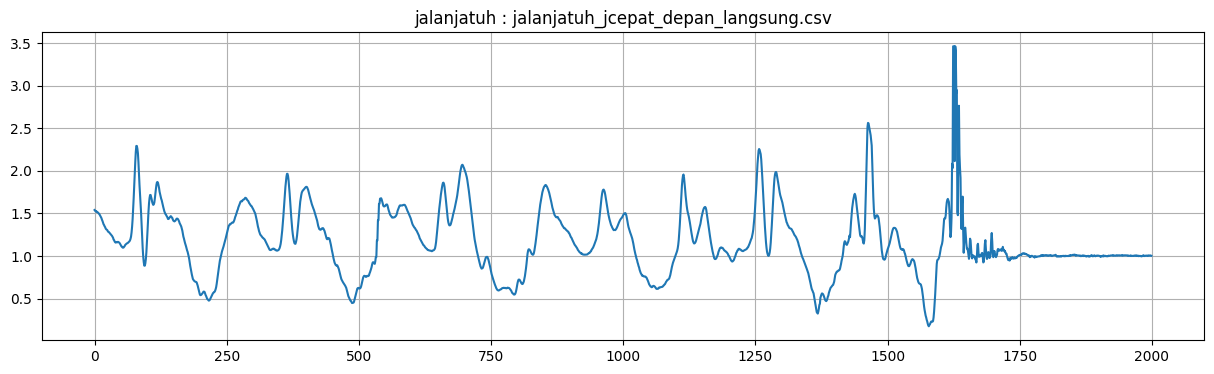

In [13]:
import random

classes = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

for cls in classes:

    folder = os.path.join(
        SAVE_PATH,
        cls
    )

    file = random.choice(
        os.listdir(folder)
    )

    fp = os.path.join(
        folder,
        file
    )

    df = pd.read_csv(fp)

    acc_mag = np.sqrt(
        df["ax"]**2 +
        df["ay"]**2 +
        df["az"]**2
    )

    plt.figure(figsize=(15,4))

    plt.plot(acc_mag)

    plt.title(
        f"{cls} : {file}"
    )

    plt.grid()

    plt.show()

In [14]:
for cls in ["diamjatuh", "jalanjatuh"]:

    folder = os.path.join(SAVE_PATH, cls)

    peaks = []

    for file in os.listdir(folder):

        fp = os.path.join(folder, file)

        df = pd.read_csv(fp)

        acc_mag = np.sqrt(
            df["ax"]**2 +
            df["ay"]**2 +
            df["az"]**2
        )

        peak_idx = np.argmax(acc_mag)

        peaks.append(peak_idx)

    print(cls)
    print("min :", np.min(peaks))
    print("max :", np.max(peaks))
    print("mean:", np.mean(peaks))

diamjatuh
min : 327
max : 1603
mean: 1134.4262295081967
jalanjatuh
min : 542
max : 1969
mean: 1298.828947368421


In [15]:
import numpy as np
import pandas as pd
import os

for cls in ["diamjatuh", "jalanjatuh"]:

    folder = os.path.join(
        SAVE_PATH,
        cls
    )

    peaks = []

    for file in os.listdir(folder):

        fp = os.path.join(folder, file)

        df = pd.read_csv(fp)

        acc_mag = np.sqrt(
            df["ax"]**2 +
            df["ay"]**2 +
            df["az"]**2
        )

        peaks.append(
            np.argmax(acc_mag)
        )

    peaks = np.array(peaks)

    print("\n", cls)

    print("Jumlah Event :", len(peaks))

    print("Min    :", peaks.min())
    print("Q1     :", np.percentile(peaks,25))
    print("Median :", np.median(peaks))
    print("Q3     :", np.percentile(peaks,75))
    print("Max    :", peaks.max())

    print("Mean   :", peaks.mean())
    print("Std    :", peaks.std())


 diamjatuh
Jumlah Event : 61
Min    : 327
Q1     : 1005.0
Median : 1111.0
Q3     : 1288.0
Max    : 1603
Mean   : 1134.4262295081967
Std    : 233.19747903878738

 jalanjatuh
Jumlah Event : 76
Min    : 542
Q1     : 1084.25
Median : 1289.5
Q3     : 1546.75
Max    : 1969
Mean   : 1298.828947368421
Std    : 307.030102594016


In [16]:
for cls in ["diamjatuh", "jalanjatuh"]:

    folder = os.path.join(
        SAVE_PATH,
        cls
    )

    peaks = []

    for file in os.listdir(folder):

        fp = os.path.join(folder, file)

        df = pd.read_csv(fp)

        acc_mag = np.sqrt(
            df["ax"]**2 +
            df["ay"]**2 +
            df["az"]**2
        )

        peaks.append(
            np.argmax(acc_mag)
        )

    peaks = np.array(peaks)

    print("\n", cls)

    print("0-500     :", np.sum((peaks >= 0) & (peaks < 500)))
    print("500-1000  :", np.sum((peaks >= 500) & (peaks < 1000)))
    print("1000-1500 :", np.sum((peaks >= 1000) & (peaks < 1500)))
    print("1500-2000 :", np.sum((peaks >= 1500) & (peaks <= 2000)))


 diamjatuh
0-500     : 1
500-1000  : 14
1000-1500 : 42
1500-2000 : 4

 jalanjatuh
0-500     : 0
500-1000  : 11
1000-1500 : 42
1500-2000 : 23


In [17]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/drive/My Drive/Colab Notebooks/datasheet_event2000_2"

classes = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

label_map = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

WINDOW_SIZE = 400
STEP = 200

X = []
y = []

for cls in classes:

    folder = os.path.join(
        DATA_PATH,
        cls
    )

    files = os.listdir(folder)

    print("\nPROCESS :", cls)

    for file in files:

        fp = os.path.join(
            folder,
            file
        )

        df = pd.read_csv(fp)

        data = df[
            ["ax","ay","az","gx","gy","gz"]
        ].values

        for start in range(
            0,
            len(data)-WINDOW_SIZE+1,
            STEP
        ):

            end = start + WINDOW_SIZE

            window = data[start:end]

            X.append(window)

            y.append(
                label_map[cls]
            )

X = np.array(X)
y = np.array(y)

print("\nX shape :", X.shape)
print("y shape :", y.shape)


PROCESS : diam

PROCESS : jalan

PROCESS : diamjatuh

PROCESS : jalanjatuh

X shape : (2187, 400, 6)
y shape : (2187,)


In [18]:
unique, counts = np.unique(
    y,
    return_counts=True
)

for u,c in zip(unique,counts):

    print(
        list(label_map.keys())[u],
        ":",
        c
    )

diam : 486
jalan : 468
diamjatuh : 549
jalanjatuh : 684


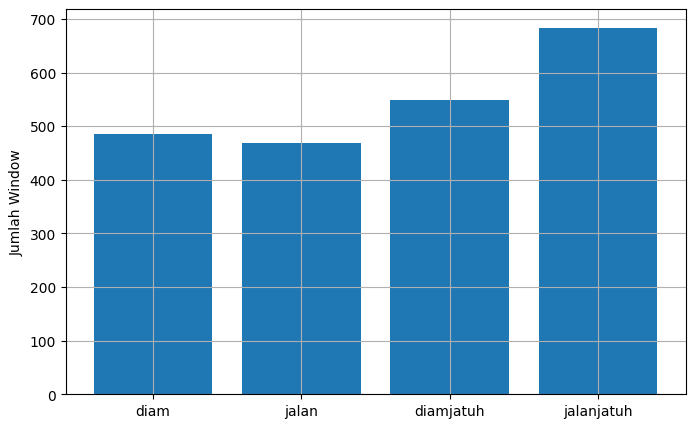

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ["diam","jalan","diamjatuh","jalanjatuh"],
    counts
)

plt.ylabel("Jumlah Window")

plt.grid()

plt.show()

In [20]:
print(X.shape)
print(y.shape)

print(
    "Contoh window:",
    X[0].shape
)

print(
    "Label pertama:",
    y[0]
)

(2187, 400, 6)
(2187,)
Contoh window: (400, 6)
Label pertama: 0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1749, 400, 6)
(438, 400, 6)


In [23]:
mean = X_train.mean(
    axis=(0,1),
    keepdims=True
)

std = X_train.std(
    axis=(0,1),
    keepdims=True
)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/My Drive/Colab Notebooks/datasheet_event2000_2"

diamjatuh_folder = os.path.join(
    DATA_PATH,
    "diamjatuh"
)

jalanjatuh_folder = os.path.join(
    DATA_PATH,
    "jalanjatuh"
)

diamjatuh_file = sorted(
    os.listdir(diamjatuh_folder)
)[0]

jalanjatuh_file = sorted(
    os.listdir(jalanjatuh_folder)
)[0]

print("Diamjatuh :", diamjatuh_file)
print("Jalanjatuh :", jalanjatuh_file)

Diamjatuh : ddiamjatuh_berdiri_kanan_tangan_20260531_022610.csv
Jalanjatuh : jalancepat_tersandung_langsung.csv


In [25]:
df_diamjatuh = pd.read_csv(
    os.path.join(
        diamjatuh_folder,
        diamjatuh_file
    )
)

df_jalanjatuh = pd.read_csv(
    os.path.join(
        jalanjatuh_folder,
        jalanjatuh_file
    )
)

print(df_diamjatuh.shape)
print(df_jalanjatuh.shape)

(2000, 8)
(2000, 8)


In [26]:
WINDOW_SIZE = 400
STEP = 200

def get_window(data, n):

    start = (n-1) * STEP
    end = start + WINDOW_SIZE

    return data[start:end]

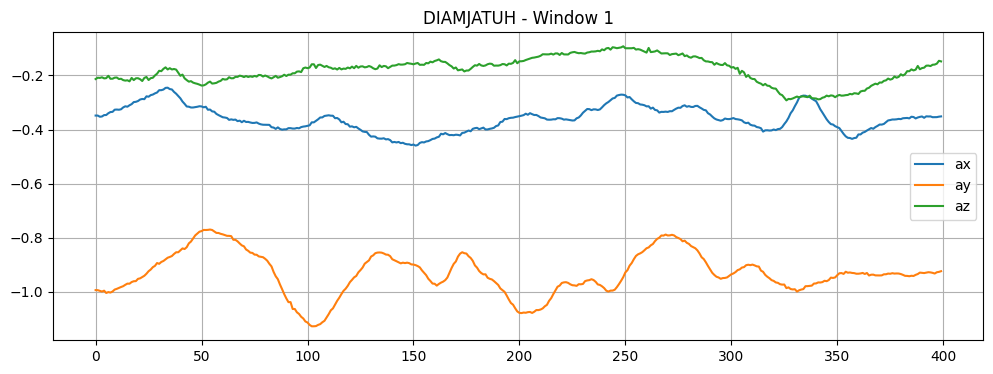

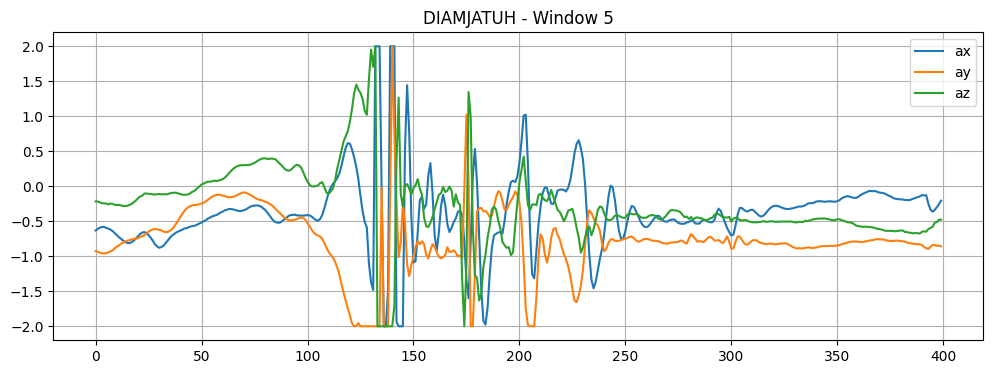

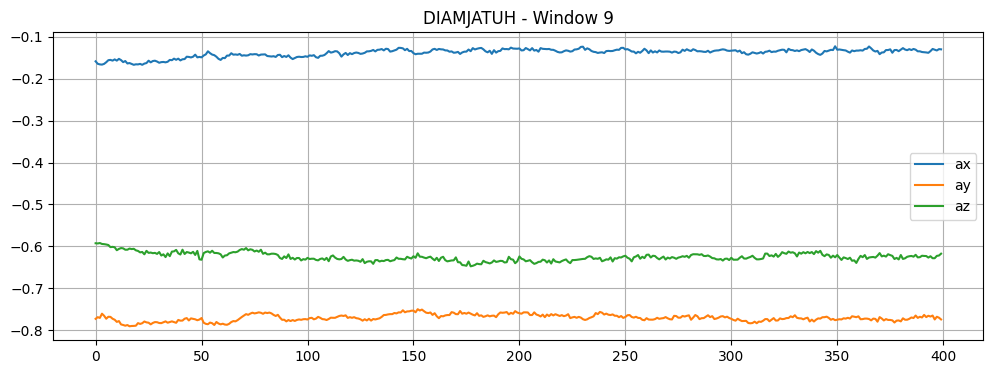

In [27]:
for w in [1,5,9]:

    window = get_window(
        df_diamjatuh[
            ["ax","ay","az"]
        ].values,
        w
    )

    plt.figure(figsize=(12,4))

    plt.plot(window[:,0], label="ax")
    plt.plot(window[:,1], label="ay")
    plt.plot(window[:,2], label="az")

    plt.title(
        f"DIAMJATUH - Window {w}"
    )

    plt.legend()
    plt.grid()

    plt.show()

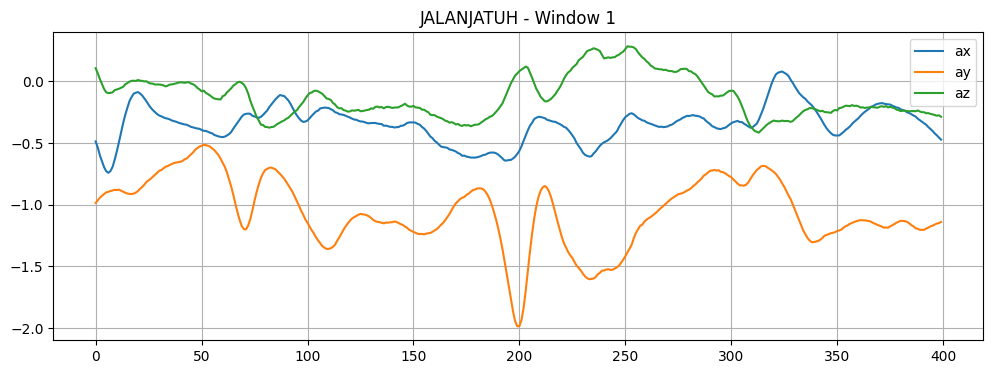

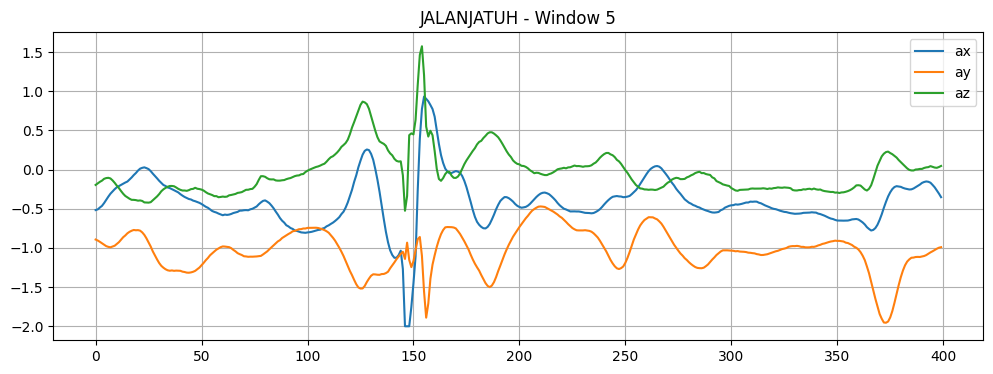

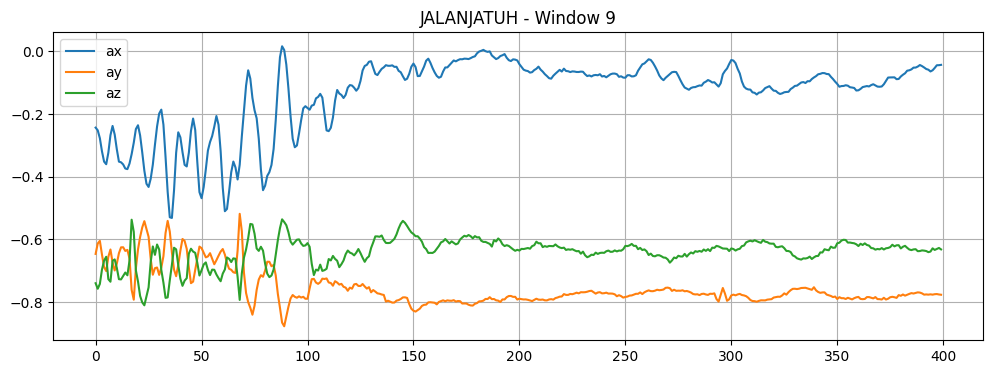

In [28]:
for w in [1,5,9]:

    window = get_window(
        df_jalanjatuh[
            ["ax","ay","az"]
        ].values,
        w
    )

    plt.figure(figsize=(12,4))

    plt.plot(window[:,0], label="ax")
    plt.plot(window[:,1], label="ay")
    plt.plot(window[:,2], label="az")

    plt.title(
        f"JALANJATUH - Window {w}"
    )

    plt.legend()
    plt.grid()

    plt.show()

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

mean = X_train.mean(
    axis=(0,1),
    keepdims=True
)

std = X_train.std(
    axis=(0,1),
    keepdims=True
)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(X_train.shape)
print(X_test.shape)

(1749, 400, 6)
(438, 400, 6)


In [30]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(

    Conv1D(
        32,
        5,
        activation="relu",
        input_shape=(400,6)
    )
)

model.add(

    Conv1D(
        32,
        5,
        activation="relu"
    )
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Dropout(0.3)
)

model.add(

    Conv1D(
        64,
        3,
        activation="relu"
    )
)

model.add(

    Conv1D(
        64,
        3,
        activation="relu"
    )
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Dropout(0.3)
)

model.add(
    GlobalAveragePooling1D()
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        4,
        activation="softmax"
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 396, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 392, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 196, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 196, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 194, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 192, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,124 (113.77 KB)

 Trainable params: 29,124 (113.77 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=50,

    batch_size=32,

    callbacks=[
        early_stop
    ]
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4637 - loss: 1.1491 - val_accuracy: 0.6005 - val_loss: 0.9291
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6295 - loss: 0.8604 - val_accuracy: 0.6667 - val_loss: 0.7776
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6810 - loss: 0.7492 - val_accuracy: 0.6872 - val_loss: 0.7619
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7090 - loss: 0.6920 - val_accuracy: 0.7306 - val_loss: 0.7002
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7193 - loss: 0.6680 - val_accuracy: 0.7169 - val_loss: 0.6761
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7238 - loss: 0.6406 - val_accuracy: 0.7055 - val_loss: 0.6852
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7336 - loss: 0.6152 - val_accuracy: 0.7283 - val_loss: 0.6212
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7439 - loss: 0.5939 - val_accuracy: 0.7146 - v

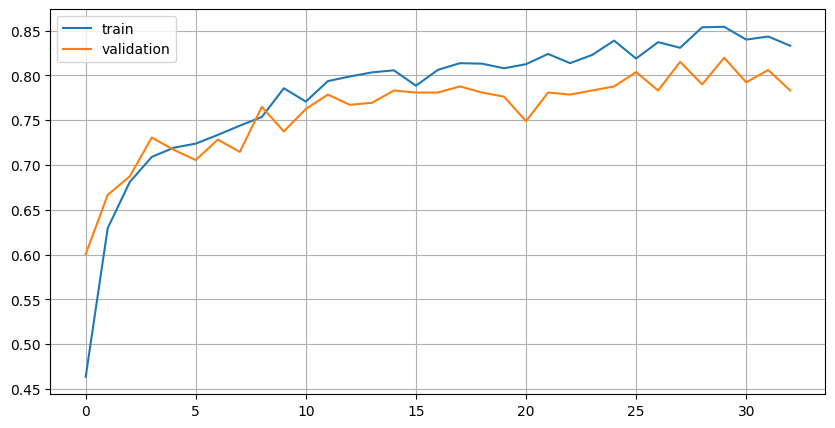

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="train"
)

plt.plot(
    history.history["val_accuracy"],
    label="validation"
)

plt.legend()

plt.grid()

plt.show()

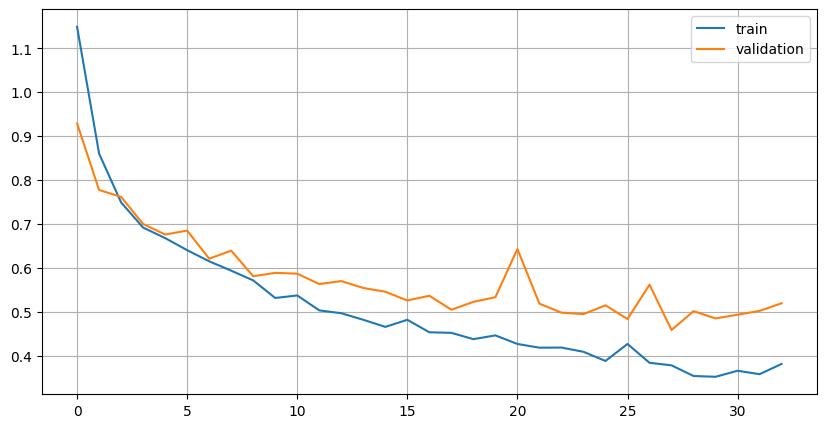

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="train"
)

plt.plot(
    history.history["val_loss"],
    label="validation"
)

plt.legend()

plt.grid()

plt.show()

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_pred = model.predict(
    X_test
)

y_pred = np.argmax(
    y_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

print(
    classification_report(
        y_test,
        y_pred
    )
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[[ 88   3   6   0]
 [  5  85   3   1]
 [ 10   2  83  15]
 [  1   4  31 101]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        97
           1       0.90      0.90      0.90        94
           2       0.67      0.75      0.71       110
           3       0.86      0.74      0.80       137

    accuracy                           0.82       438
   macro avg       0.82      0.83      0.82       438
weighted avg       0.82      0.82      0.82       438



In [36]:
model.save(
    "fall_detection_cnn2.h5"
)

In [37]:
from google.colab import files

files.download(
    "fall_detection_cnn2.h5"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 396, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 392, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 196, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 196, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 194, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 192, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,374 (341.31 KB)

 Trainable params: 29,124 (113.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,250 (227.54 KB)

In [40]:
from tensorflow.keras.models import load_model

model = load_model(
    "fall_detection_cnn2.h5"
)

input_tensor = Input(
    shape=X_test.shape[1:]
)

x = input_tensor

for layer in model.layers[:-2]:

    x = layer(x)

feature_model = Model(
    inputs=input_tensor,
    outputs=x
)

In [41]:
features = feature_model.predict(
    X_test
)

print(features.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(438, 64)


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(
    features
)

In [44]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    features_scaled
)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

Explained Variance: [0.4198036  0.23628461]


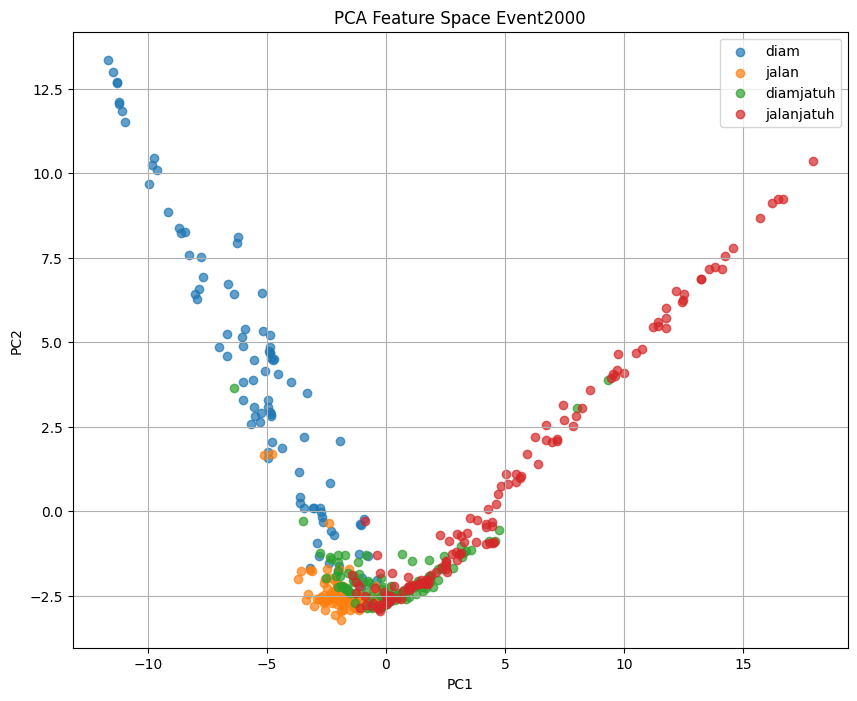

In [45]:
import matplotlib.pyplot as plt

class_names = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

plt.figure(figsize=(10,8))

for i in range(4):

    idx = np.where(
        y_test == i
    )

    plt.scatter(
        pca_result[idx,0],
        pca_result[idx,1],
        alpha=0.7,
        label=class_names[i]
    )

plt.title(
    "PCA Feature Space Event2000"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()

plt.grid()

plt.show()

In [46]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_result = tsne.fit_transform(
    features_scaled
)

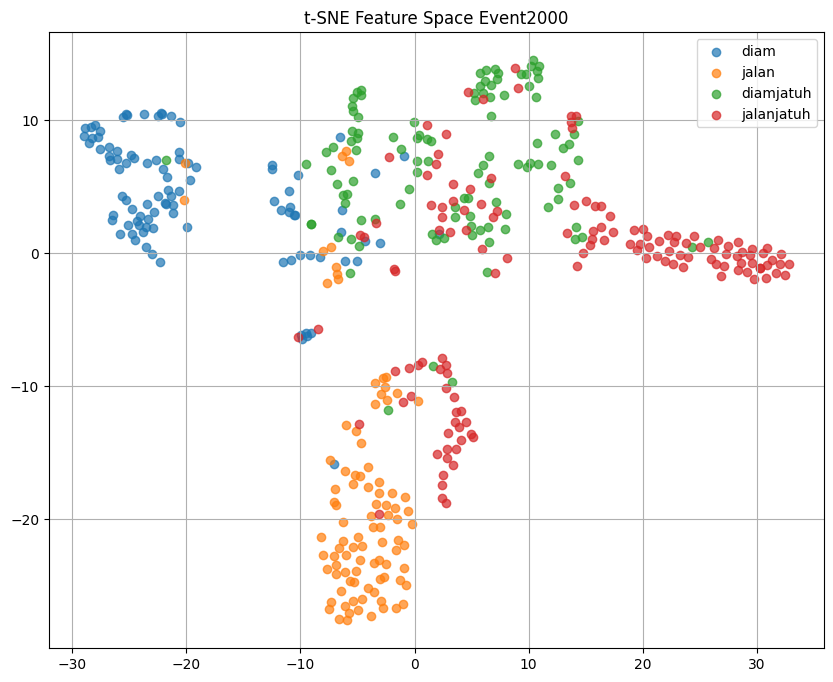

In [47]:
plt.figure(figsize=(10,8))

for i in range(4):

    idx = np.where(
        y_test == i
    )

    plt.scatter(
        tsne_result[idx,0],
        tsne_result[idx,1],
        alpha=0.7,
        label=class_names[i]
    )

plt.title(
    "t-SNE Feature Space Event2000"
)

plt.legend()

plt.grid()

plt.show()

In [48]:
import pandas as pd

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1","PC2"]
)

pca_df["label"] = y_test

for i,name in enumerate(class_names):

    subset = pca_df[
        pca_df["label"] == i
    ]

    print("\n",name)

    print(
        "PC1 mean:",
        subset["PC1"].mean()
    )

    print(
        "PC2 mean:",
        subset["PC2"].mean()
    )


 diam
PC1 mean: -5.210076
PC2 mean: 3.784425

 jalan
PC1 mean: -1.7538565
PC2 mean: -2.420092

 diamjatuh
PC1 mean: 0.26570165
PC2 mean: -1.9661123

 jalanjatuh
PC1 mean: 4.6789246
PC2 mean: 0.5596484


In [49]:
from scipy.spatial.distance import euclidean

centroids = {}

for i,name in enumerate(class_names):

    subset = pca_df[
        pca_df["label"] == i
    ]

    centroids[name] = [
        subset["PC1"].mean(),
        subset["PC2"].mean()
    ]

print("\nJARAK ANTAR KELAS")

for c1 in class_names:

    for c2 in class_names:

        if c1 < c2:

            d = euclidean(
                centroids[c1],
                centroids[c2]
            )

            print(
                c1,
                "<->",
                c2,
                ":",
                round(d,3)
            )


JARAK ANTAR KELAS
diam <-> jalan : 7.102
diam <-> diamjatuh : 7.941
diam <-> jalanjatuh : 10.402
jalan <-> jalanjatuh : 7.089
diamjatuh <-> jalan : 2.07
diamjatuh <-> jalanjatuh : 5.085


In [50]:
for i,name in enumerate(class_names):

    subset = pca_df[
        pca_df["label"] == i
    ]

    print("\n",name)

    print(
        subset[["PC1","PC2"]]
        .describe()
    )


 diam
             PC1        PC2
count  97.000000  97.000000
mean   -5.210076   3.784425
std     2.973736   4.239677
min   -11.673909  -2.876683
25%    -6.694182   0.087357
50%    -4.908220   3.495616
75%    -2.913511   6.420789
max    -0.231832  13.354796

 jalan
             PC1        PC2
count  94.000000  94.000000
mean   -1.753857  -2.420092
std     1.025541   0.717054
min    -5.115034  -3.212722
25%    -2.394457  -2.718968
50%    -1.858032  -2.590024
75%    -1.114448  -2.416169
max     0.565095   1.689290

 diamjatuh
              PC1         PC2
count  110.000000  110.000000
mean     0.265702   -1.966112
std      2.119034    1.077492
min     -6.392594   -2.870717
25%     -1.175797   -2.510940
50%     -0.016353   -2.242328
75%      1.236417   -1.720196
max      9.333293    3.884267

 jalanjatuh
              PC1         PC2
count  137.000000  137.000000
mean     4.678925    0.559648
std      4.925386    3.530052
min     -1.410301   -2.967033
25%      0.635921   -2.212918
50%   

In [51]:
print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance: [0.4198036  0.23628461]
Total: 0.65608823
